# Full 3D Pose Estimation Pipeline
This notebook combines 2D pose detection and 3D reconstruction steps.

In [1]:
import os
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO
import pickle
from scipy.optimize import least_squares, minimize

from helpers.predictors import *
from helpers.json_handling import read_keypoints_mmpose
from helpers.camera import *
from helpers.definitions import *
from helpers.plotting import *
from helpers.pose_construction import *

from helpers.weakloss import BMCLoss

# Configuration
data_collection = 'cha/cha_short'  # Change this to match your data collection
show = True  # Show visualizations
resolution = (960, 540)  # Processing resolution
original_resolution = (3840, 2160)  # Original video resolution
max_hands = 2  # Maximum number of hands to track per person

# Camera configuration
far_field_cameras = []  # Specify which cameras to use
near_field_cameras = []  # Specify which cameras to use
for i in range(1, 13):
    if i < 5:
        far_field_cameras.append('gopro' + str(i))
    else:
        near_field_cameras.append('gopro' + str(i))


Device: cuda
Torch compile enabled: True


## Initialize Models
Initialize all required models for detection and pose estimation.

In [2]:
# Initialize YOLO models for hand detection
model_person = YOLO('checkpoints/yolo/yolo11l.pt')
model_hand = YOLO('checkpoints/yolo/rohan_pretrained.pt')

# Configure model settings
model_hand.conf = 0.3  # NMS confidence threshold
model_hand.iou = 0.3   # NMS IoU threshold

# Initialize models with TAM tracker
USE_TAM = True
initialize_models(use_tam=USE_TAM)

# Set up paths
data_dir = f'inputs/{data_collection}'  # Input video directory
pose_output_dir = f'pose_outputs/{data_collection}'  # 2D pose output directory
output_3d_dir = f'output_3d/{data_collection}'  # 3D pose output directory
detection_dir = f'outputs/{data_collection}'  # Directory containing detection txt files

os.makedirs(pose_output_dir, exist_ok=True)
os.makedirs(output_3d_dir, exist_ok=True)

Loads checkpoint by local backend from path: checkpoints/hands/detection/cascade_rcnn_x101_64x4d_fpn_20e_onehand10k-dac19597_20201030.pth
Loads checkpoint by local backend from path: checkpoints/body/detection/rtmdet_m_8xb32-100e_coco-obj365-person-235e8209.pth
Disable torch compile due to unsupported GPU.
Loads checkpoint by local backend from path: checkpoints/hands/pose/rtmpose-m_simcc-hand5_pt-aic-coco_210e-256x256-74fb594_20230320.pth
Loads checkpoint by local backend from path: checkpoints/body/pose/rtmpose-x_simcc-body7_pt-body7-halpe26_700e-384x288-7fb6e239_20230606.pth


c:\Users\aelvy\miniconda3\envs\orpose\Lib\site-packages\mmengine\utils\manager.py:113: UserWarning: <class 'mmpose.visualization.local_visualizer.PoseLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


Models initialized with EfficientTAM tracker
Pose estimation models initialized
YOLO models initialized


## Process Videos and Extract 2D Poses

In [3]:
def process_single_video(video_name):
    """Process a single video to extract 2D poses"""
    video_path = os.path.join(data_dir, f"{video_name}.MP4")
    if not os.path.exists(video_path):
        print(f"Video not found: {video_path}")
        return False

    print(f"Processing {video_name}...")

    # Process frames and estimate poses
    pred_instances_body = []
    cap = cv2.VideoCapture(video_path)

    if os.path.exists(os.path.join(pose_output_dir, f"{video_name}_body.json")):
        print(f"Skipping {video_name} - already processed")
        return int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Detect body poses
    bboxes_body = detect_body(video_path)

    frame_idx = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
            
        # Estimate body pose
        bbox = np.array(bboxes_body[frame_idx])
        if len(bbox.shape) == 1:
            bbox = bbox.reshape((1, 4))
            
        pred_instances = estimate_pose(frame, bbox, pose_type='body', show=False)
        
        # Convert instances to JSON-serializable format
        instances_json = []
        if pred_instances is not None:
            for instance in split_instances(pred_instances):
                instance_json = {
                    'keypoints': np.array(instance['keypoints']).astype(float).tolist(),
                    'keypoint_scores': np.array(instance['keypoint_scores']).astype(float).tolist()
                }
                if 'bbox' in instance:
                    instance_json['bbox'] = np.array(instance['bbox']).astype(float).tolist()
                    if 'bbox_score' in instance:
                        instance_json['bbox_score'] = float(instance['bbox_score'])
                instances_json.append(instance_json)

        pred_instances_body.append(dict(
            frame_id=frame_idx,
            instances=instances_json
        ))
        
        frame_idx += 1
        print(f"\rProcessing frame {frame_idx}", end='')

    print(". Done!")
        
    cap.release()
    
    # Save predictions
    save_path = os.path.join(pose_output_dir, f"{video_name}_body.json")
    with open(save_path, 'w') as f:
        json.dump({
            'instance_info': pred_instances_body
        }, f, indent=2)
        
    return frame_idx

# Process all videos
for video_file in os.listdir(data_dir):
    if video_file.endswith('.MP4'):
        video_name = os.path.splitext(video_file)[0]
        # Check if video is from an allowed camera
        if any(video_name.startswith(cam + '_') for cam in far_field_cameras):
            total_frames = process_single_video(video_name)
        else:
            print(f"Skipping {video_name} - not in far field cameras list")

Skipping gopro10_synced_cut - not in far field cameras list
Skipping gopro11_synced_cut - not in far field cameras list
Skipping gopro12_synced_cut - not in far field cameras list
Skipping gopro13_synced_cut - not in far field cameras list
Processing gopro1_synced_cut...
Skipping gopro1_synced_cut - already processed
Processing gopro2_synced_cut...
Skipping gopro2_synced_cut - already processed
Processing gopro3_synced_cut...
Skipping gopro3_synced_cut - already processed
Processing gopro4_synced_cut...
Skipping gopro4_synced_cut - already processed
Skipping gopro5_synced_cut - not in far field cameras list
Skipping gopro6_synced_cut - not in far field cameras list
Skipping gopro7_synced_cut - not in far field cameras list
Skipping gopro8_synced_cut - not in far field cameras list
Skipping gopro9_synced_cut - not in far field cameras list


## Reconstruct 3D Poses
Load 2D poses and camera parameters, then reconstruct 3D poses.

Hand keypoints not available for cam: gopro1
Hand keypoints not available for cam: gopro2
Hand keypoints not available for cam: gopro3
Hand keypoints not available for cam: gopro4
Body keypoints not available for cam: gopro5
Hand keypoints not available for cam: gopro5
Body keypoints not available for cam: gopro6
Hand keypoints not available for cam: gopro6
Body keypoints not available for cam: gopro7
Hand keypoints not available for cam: gopro7
Body keypoints not available for cam: gopro8
Hand keypoints not available for cam: gopro8
Body keypoints not available for cam: gopro9
Hand keypoints not available for cam: gopro9
Body keypoints not available for cam: gopro10
Hand keypoints not available for cam: gopro10
Body keypoints not available for cam: gopro11
Hand keypoints not available for cam: gopro11
Body keypoints not available for cam: gopro12
Hand keypoints not available for cam: gopro12


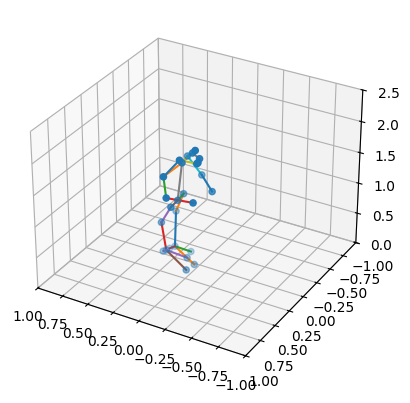

In [4]:
# Load camera parameters
camera_params_dir = f'camera_poses/{data_collection.split("/")[0]}'


camera_intrinsics, camera_extrinsics, distortion_coeffs, camera_matrices = load_camera_params(
    os.path.join(camera_params_dir, 'camera_intrinsics'),
    os.path.join(camera_params_dir, 'camera_extrinsics/aligned_poses.json'),
    suffix='_synced',
    named=True,
    import_extrinsics_matrix=True
)

far_field_cam_intr = [camera_intrinsics[cam] for cam in far_field_cameras]
far_field_cam_extr = [camera_extrinsics[cam] for cam in far_field_cameras]
far_field_cam_dist = [distortion_coeffs[cam] for cam in far_field_cameras]
far_field_cam_mat = [camera_matrices[cam] for cam in far_field_cameras]

# Read 2D keypoints from JSON files
poses_2d_body, _ = read_keypoints_mmpose(
    pose_output_dir, 
    cam_names, 
    num_frames=total_frames,  # Use dynamically determined frame count
    suffix='_synced_cut'
)

# Mask keypoints based on confidence
poses_2d_masked = mask_keypoints(
    poses_2d_body, 
    confidence_threshold=0.3, 
    min_cameras=2, 
    num_keypoints=26
)

# Reconstruct 3D poses
poses_3d_body = reconstruct_3d_pose(
    poses_2d_masked,
    far_field_cam_intr,
    far_field_cam_extr,
    far_field_cam_dist,
    far_field_cam_mat,
    regularization_weight=1.0,
    reprojection_weight=1.0,
    smoothing=True
)

# Save results
output_file = os.path.join(output_3d_dir, 'poses_3d.npz')
np.savez(
    output_file,
    poses_2d=poses_2d_body,
    poses_3d=poses_3d_body
)

# Visualize results
if show:
    pose2video(
        poses_3d_body,
        output_3d_dir,
        'visualization',
        xlim=(1, -1),
        ylim=(1, -1),
        zlim=(0, 2.5)
    )

## Hand Detection and Tracking
Using pre-trained YOLO models for person and hand detection, followed by hand pose estimation and tracking. The system first detects persons using YOLOv8, then searches for hands within detected person regions using a specialized hand detection model.

In [5]:

def crop_img(img, box):
    """Crop image based on bounding box"""
    x1, y1, x2, y2 = box
    return img[int(y1):int(y2), int(x1):int(x2)]

def detect_hands_in_frame(frame):
    """Detect hands in a single frame using YOLO model"""
    # Process frame with YOLO
    results = model_person(frame, classes=0)
    # print(results)
    boxes = []
    confidence = []
    
    if len(results) == 0:
        results_hands = model_hand(frame)
        for r in results_hands:
            boxes_tensor = r.boxes.xyxy.cpu()
            confs = r.boxes.conf.cpu()
            for box, conf in zip(boxes_tensor, confs):
                if conf > model_hand.conf:
                    boxes.append(box.flatten())
                    confidence.append(conf)
    # Process detections
    for r in results:
        boxes_tensor = r.boxes.xyxy.cpu()
        confs = r.boxes.conf.cpu()
        for box1, conf in zip(boxes_tensor, confs):
            cropped = crop_img(frame, box1)
            results_hands = model_hand(cropped)
            for r in results_hands:
                boxes_tensor = r.boxes.xyxy.cpu()
                confs = r.boxes.conf.cpu()
                for box2, conf in zip(boxes_tensor, confs):
                    if conf > model_hand.conf:
                        # print(box2)
                        adjusted_box = np.add(np.array(box2).reshape(2, 2), box1[:2])
                        boxes.append(adjusted_box.flatten())
                        confidence.append(conf)
                       
                
    return np.array(boxes) if boxes else np.array([]), np.array(confidence) if confidence else np.array([])

def process_video_rohan(input_file, show=True):
    """Process video file for hand detection"""
    cap = cv2.VideoCapture(input_file)
    if not cap.isOpened():
        raise FileNotFoundError(f"Cannot open video file: {input_file}")
    
    frame_idx = 0
    output_boxes = []
    out_frame_idx = None
    
    success = True
    while cap.isOpened() and success:   
        success, frame = cap.read()
        if not success:
            break
            
        # Detect hands
        boxes, confidence = detect_hands_in_frame(frame)
        
        if len(boxes) > 0:
            output_boxes.append((boxes, confidence, frame_idx))
            
        if show:
            # Visualize detections
            for box, conf in zip(boxes, confidence):
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 255), 2)
                cv2.putText(frame, f"Hand, conf: {round(100*conf, 1)}%", (x1 - 30, y1 - 30), cv2.FONT_HERSHEY_PLAIN, 2, (255, 0, 255), 2)
            
            cv2.namedWindow('Detections', cv2.WINDOW_NORMAL)
            cv2.resizeWindow('Detections', 1920, 1080)
            cv2.imshow('Detections', frame)
            if cv2.waitKey(1) == 113:
                success = False

                
        frame_idx += 1
        print(f"Processing frame {frame_idx}", end='\r')
    
    cap.release()
    if show:
        cv2.destroyAllWindows()
        
    return output_boxes

def save_to_file(boxes, output_file):
    
    # Save output to file
    with open(output_file, 'w+') as f:
        for boxes, conf, frame_idx in boxes:
            f.write(f"{frame_idx} ")
            for i, box in enumerate(boxes):
                f.write(f"{box[0]} {box[1]} {box[2]} {box[3]} {conf[i]} ")
            f.write("\n")

In [6]:
# Process all videos in the inputs folder
for video_file in os.listdir(data_dir):
    if video_file.endswith('.MP4'):
        video_name = os.path.splitext(video_file)[0]
        if any(video_name.startswith(cam) for cam in near_field_cameras):
            print(f"\nProcessing video: {video_name}")
            video_path = os.path.join(data_dir, video_file)

            if os.path.exists(f"outputs/{data_collection}/{video_name}.txt"):
                print("Output already exists, skipping")
                continue
            # Process the video
            bboxes = process_video_rohan(video_path, show=show)
            
            if len(bboxes) == 0:
                print("No hands detected")
            else:
                (boxes, conf, frame_idxs) = zip(*bboxes)
                print(f"\nFound hands at frame {frame_idxs}")
                print(f"Bounding boxes: \n{boxes}")

                os.makedirs(f"outputs/{data_collection}", exist_ok=True)
                save_to_file(bboxes, f"outputs/{data_collection}/{video_name}.txt")


Processing video: gopro10_synced_cut
Output already exists, skipping

Processing video: gopro11_synced_cut
Output already exists, skipping

Processing video: gopro12_synced_cut

0: 384x640 (no detections), 56.8ms
Speed: 4.7ms preprocess, 56.8ms inference, 110.8ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 1
0: 384x640 (no detections), 31.2ms
Speed: 2.7ms preprocess, 31.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 2
0: 384x640 (no detections), 24.0ms
Speed: 0.0ms preprocess, 24.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 3
0: 384x640 (no detections), 27.8ms
Speed: 3.6ms preprocess, 27.8ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 4
0: 384x640 (no detections), 23.0ms
Speed: 2.3ms preprocess, 23.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)
Processing frame 5
0: 384x640 (no detections), 19.6ms
Speed: 14.6ms preprocess, 19.

## Hand Tracking with EfficientTAM
This section handles hand tracking using the EfficientTAM algorithm. The process first detects people and hands using YOLO models, then uses EfficientTAM to track detected hands through video sequences. This enables robust hand tracking even with rapid movements and partial occlusions.

In [7]:
def read_detection_file(filepath, with_confidence=False):
    """Read detection file containing frame index and bounding boxes"""
    detections = {}
    stride = 5 if with_confidence else 4
    with open(filepath, 'r') as f:
        for line in f:
            values = list(map(float, line.strip().split()))
            frame_idx = int(values[0])
            boxes = []
            # Each box has 4 coordinates
            for i in range(1, len(values), stride):
                boxes.append(values[i:i+4])

            boxes = np.array(boxes)

            if resolution != original_resolution:
                # Rescale bounding boxes to original resolution
                
                boxes[:, 0] *= resolution[0] / original_resolution[0]
                boxes[:, 1] *= resolution[1] / original_resolution[1]
                boxes[:, 2] *= resolution[0] / original_resolution[0]
                boxes[:, 3] *= resolution[1] / original_resolution[1]
            detections[frame_idx] = boxes
    return detections

def prepare_video_frames(video_path, resample_to=None):
    """Create frames directory if video file exists"""
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")
        
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    frames_dir = os.path.join(os.path.dirname(video_path), video_name)
    
    if not os.path.exists(frames_dir):
        os.makedirs(frames_dir)
        cap = cv2.VideoCapture(video_path)
        frame_idx = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if resample_to is not None:
                frame = cv2.resize(frame, resample_to)
            cv2.imwrite(os.path.join(frames_dir, f"{frame_idx:05d}.jpg"), frame)
            frame_idx += 1
            
        cap.release()
        
    return frames_dir

In [8]:

def process_video_hands(video_name):
    """Process a single video file and track all boxes as one object"""

    def box_tracked(tracks, frame_idx, box):
        """Check if box is already tracked in the tracks"""

        box_mean_x = (box[0] + box[2]) / 2
        box_mean_y = (box[1] + box[3]) / 2
        if frame_idx not in tracks:
            return False

        for tracked_box in tracks[frame_idx].values():
            if len(tracked_box) == 0:
                continue
            tracked_box = tracked_box.flatten()
            tracked_box_mean_x = (tracked_box[0] + tracked_box[2]) / 2
            tracked_box_mean_y = (tracked_box[1] + tracked_box[3]) / 2
            tracked_in_box = (tracked_box_mean_x >= box[0] and tracked_box_mean_x <= box[2] and tracked_box_mean_y >= box[1] and tracked_box_mean_y <= box[3])
            box_in_tracked = (box_mean_x >= tracked_box[0] and box_mean_x <= tracked_box[2] and box_mean_y >= tracked_box[1] and box_mean_y <= tracked_box[3])
            if tracked_in_box and box_in_tracked:
                return True
        return False

    def is_hand(frame_idx, box, frames_dir):
        """Check if box really detected a hand"""
        # Load the frame
        frame = cv2.imread(os.path.join(frames_dir, f"{frame_idx:05d}.jpg"))
        box = box.astype(int)
        print(box)

        # Predict hand pose
        pose = estimate_pose(frame, box, pose_type='hand', show=False, write_img=None)
        print(np.mean(pose.keypoint_scores), IS_HAND_THRESHOLD)
        print(np.max(pose.keypoint_scores), IS_HAND_THRESHOLD)
        print(np.mean(pose.keypoint_scores) >= IS_HAND_THRESHOLD, np.max(pose.keypoint_scores) >= IS_HAND_THRESHOLD)
        if np.mean(pose.keypoint_scores) >= IS_HAND_THRESHOLD:
            return True
        return False


    # Get paths
    video_path = os.path.join(data_dir, f"{video_name}.MP4")
    detection_path = os.path.join(detection_dir, f"{video_name}.txt")

    if not os.path.exists(detection_path):
        print(f"No detection file found for {video_name}")
        return None, None

    # Prepare video frames
    frames_dir = prepare_video_frames(video_path, resolution)

    # Read detections
    detections = read_detection_file(detection_path, with_confidence=True)

    # Initialize tracker for all boxes under single ID
    obj_id = 0
    all_tracks = None
    predictor = None
    inference_state = None
    frame_names = None

    # Process each frame with detections
    for frame_idx, boxes in detections.items():
        for box in boxes:
            if (all_tracks is None or not box_tracked(all_tracks, frame_idx, box)) and obj_id < max_hands:
                print(f"Frame {frame_idx}: {box}")
                print(f"Object ID: {obj_id}")
                # Initialize tracker with first frame's boxes if not done yet
                inference_state, predictor, frame_names = add_object(
                    frames_dir,
                    input_box=box,
                    frame_idx=frame_idx,
                    obj_id=obj_id,
                    show=show,
                    inference_state=inference_state,
                    predictor_in=predictor)

                # Track the object through video
                _, track_boxes = track_object(
                    frames_dir,
                    inference_state,
                    predictor,
                    frame_names,
                    show=show,
                    prev_bboxes=None,
                    whole_mask=True)

                obj_id += 1
                all_tracks = track_boxes

    if frame_names is None:
        return None, None

    return all_tracks, frame_names

def adjust_tracks(tracks, adj_resolution=resolution, orig_resolution=original_resolution):
    for frame_idx, frame_tracks in tracks.items():
        for obj_id, box in frame_tracks.items():
            box = box.flatten()
            if len(box) == 0:
                continue
            box[0] *= orig_resolution[0] / adj_resolution[0]
            box[1] *= orig_resolution[1] / adj_resolution[1]
            box[2] *= orig_resolution[0] / adj_resolution[0]
            box[3] *= orig_resolution[1] / adj_resolution[1]
            tracks[frame_idx][obj_id] = box
    return tracks

In [9]:
def draw_pose(frame, pred_instance, pose_type='body'):
    """Draw pose keypoints and connections on frame"""
    if pose_type == 'hand':
        # Hand keypoint colors
        colors = [(255, 0, 0),   # thumb - red
                 (0, 255, 0),    # index - green
                 (0, 0, 255),    # middle - blue
                 (255, 255, 0),  # ring - yellow
                 (255, 0, 255)]  # pinky - magenta
        
        # Hand connections (finger joints)
        connections = [
            # Thumb
            (0, 1), (1, 2), (2, 3), (3, 4),
            # Index
            (0, 5), (5, 6), (6, 7), (7, 8),
            # Middle
            (0, 9), (9, 10), (10, 11), (11, 12),
            # Ring
            (0, 13), (13, 14), (14, 15), (15, 16),
            # Pinky
            (0, 17), (17, 18), (18, 19), (19, 20)
        ]

        # Draw keypoints and connections
        keypoints = pred_instance.keypoints.squeeze()
        scores = pred_instance.keypoint_scores.squeeze()
        
        # Draw connections first
        for idx, conn in enumerate(connections):
            if scores[conn[0]] > IS_HAND_THRESHOLD and scores[conn[1]] > IS_HAND_THRESHOLD:
                pt1 = tuple(map(int, keypoints[conn[0]]))
                pt2 = tuple(map(int, keypoints[conn[1]]))
                finger_idx = idx // 4  # Determine which finger
                cv2.line(frame, pt1, pt2, colors[finger_idx], POSE_VIS_LINE_WIDTH)

        # Draw keypoints
        for i, (point, score) in enumerate(zip(keypoints, scores)):
            if score > IS_HAND_THRESHOLD:  # Only draw high-confidence keypoints
                x, y = map(int, point)
                finger_idx = (i - 1) // 4 if i > 0 else 0  # Determine which finger the point belongs to
                cv2.circle(frame, (x, y), POSE_VIS_RADIUS, colors[finger_idx], -1)

    elif pose_type == 'body':
        # Draw body keypoints and connections using existing logic
        # ...existing code for body pose drawing...
        # Body keypoint colors - using consistent colors for different body parts
        colors = {
            'torso': (255, 0, 0),      # red
            'head': (0, 255, 0),       # green
            'arms': (0, 0, 255),       # blue
            'legs': (255, 255, 0)      # yellow
        }

        # Body connections based on MMPose skeleton
        connections = [
            # Torso
            ([5, 6], colors['torso']),      # shoulders
            ([5, 11], colors['torso']),     # left shoulder to hip
            ([6, 12], colors['torso']),     # right shoulder to hip
            ([11, 12], colors['torso']),    # hips
            
            # Head
            ([5, 3], colors['head']),       # left shoulder to neck
            ([6, 3], colors['head']),       # right shoulder to neck
            ([3, 1], colors['head']),       # neck to head
            
            # Arms
            ([5, 7], colors['arms']),       # left arm
            ([7, 9], colors['arms']),       # left forearm
            ([6, 8], colors['arms']),       # right arm
            ([8, 10], colors['arms']),      # right forearm
            
            # Legs
            ([11, 13], colors['legs']),     # left thigh
            ([13, 15], colors['legs']),     # left calf
            ([12, 14], colors['legs']),     # right thigh
            ([14, 16], colors['legs']),     # right calf

        ]

        # Draw keypoints and connections
        keypoints = pred_instance.keypoints.squeeze()
        scores = pred_instance.keypoint_scores.squeeze()

        # Draw connections first
        for (conn, color) in connections:
            if scores[conn[0]] > POSE_KPT_THRESHOLD and scores[conn[1]] > POSE_KPT_THRESHOLD:
                pt1 = tuple(map(int, keypoints[conn[0]]))
                pt2 = tuple(map(int, keypoints[conn[1]]))
                cv2.line(frame, pt1, pt2, color, POSE_VIS_LINE_WIDTH)

        # Draw keypoints
        for i, (point, score) in enumerate(zip(keypoints, scores)):
            if score > POSE_KPT_THRESHOLD:  # Only draw high-confidence keypoints
                x, y = map(int, point)
                cv2.circle(frame, (x, y), POSE_VIS_RADIUS, (255, 255, 255), -1)

def process_and_visualize_poses(video_path, tracks, output_dir):
    """Process and visualize body and hand poses"""
    cap = cv2.VideoCapture(video_path)
    video_name = os.path.splitext(os.path.basename(video_path))[0]
    out_path = os.path.join(output_dir, f"{video_name}_poses.mp4")
    
    # Setup video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(out_path, fourcc, 30.0, (int(cap.get(3)), int(cap.get(4))))

    hand_poses_2d = []
    frame_idx = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # Project 3D poses to 2D for this camera and frame
        if frame_idx < len(poses_3d_body):
            pose_3d = poses_3d_body[frame_idx]
            # Get camera parameters for this video
            cam_name = video_name.split('_')[0]  # Extract camera name from video name
            if cam_name in camera_matrices:
                cam_intrinsics = camera_intrinsics[cam_name].reshape(3,3)
                cam_extrinsics = camera_extrinsics[cam_name]
                cam_distortion = distortion_coeffs[cam_name]
                
                points_2d = project_points(pose_3d, cam_intrinsics, cam_extrinsics[0], cam_extrinsics[1], cam_distortion)
                
                # Create a body pose instance with the projected points
                body_pose = type('', (), {})()  # Create empty object
                body_pose.keypoints = np.array(points_2d).reshape(-1, 2)
                body_pose.keypoint_scores = np.ones(len(points_2d))  # Assuming all points are valid
                
            else:
                body_pose = None
        else:
            body_pose = None

        hand_pose_2d = {}
        # Estimate hand poses for tracked hands
        if frame_idx in tracks:
            for hand_id, box in tracks[frame_idx].items():
                hand_pose = estimate_pose(frame, box, pose_type='hand', show=False)
                # Draw hand keypoints
                if hand_pose is not None:
                    draw_pose(frame, hand_pose, pose_type='hand')
                    hand_pose_2d[hand_id] = hand_pose
            
        hand_poses_2d.append(hand_pose_2d)
                    
        # Draw body keypoints
        if body_pose is not None:
            draw_pose(frame, body_pose, pose_type='body')

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()

    return hand_poses_2d

In [10]:
# Process near field cameras for hand poses
hand_poses_2d = {}
output_file = os.path.join(output_3d_dir, 'hand_poses_2d.npz')
if os.path.exists(output_file):
    print("Hand poses already found, skipping")
    hand_poses_2d = np.load(output_file, allow_pickle=True)['poses_2d'].item()
    
else:
    for video_file in os.listdir(data_dir):
        if video_file.endswith('.MP4'):
            video_name = os.path.splitext(video_file)[0]
            if any(video_name.startswith(cam) for cam in near_field_cameras):
                cam_name = video_name.split('_')[0]
                print(f"\nProcessing {video_name} for hand detection and tracking...")
                video_path = os.path.join(data_dir, video_file)
                
                if os.path.exists(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl")):
                    print(f"Tracks already found for {video_name}")

                    with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'rb') as f:
                        tracks = pickle.load(f)

                else:
                    # Track hands
                    tracks, frame_names = process_video_hands(video_name)

                    if tracks is not None:
                        # Save tracked boxes
                        with open(os.path.join(detection_dir, f"tracked_bboxes_{video_name}.pkl"), 'wb') as f:
                            tracks = adjust_tracks(tracks)
                            pickle.dump(tracks, f)
                
                if tracks is not None: 
                    # Process and visualize poses
                    hand_poses_2d[cam_name] = process_and_visualize_poses(video_path, tracks, pose_output_dir)

    # Save hand poses to file
    np.savez(
        output_file,
        poses_2d=hand_poses_2d,
    )

Hand poses already found, skipping


In [11]:
def match_hand_poses(oriented_hands, pose_2d_dict, camera_intrinsics, rotation, translation, distortion, threshold=120, just_wrist=True):
    """
    Match 3D hand pose with corresponding 2D hand detection based on reprojection error.
    
    Args:
        oriented_hand: numpy array (2*num_keypoints_hands, 3) representing 3D hand poses
        pose_2d_dict: dictionary mapping object IDs to 2D hand poses
        camera_intrinsics: camera intrinsic matrix
        rotation: camera rotation matrix
        translation: camera translation vector
        distortion: distortion coefficients
        threshold: maximum allowed reprojection error for matching
        
    Returns:
        best_match: best matching 2D pose or None if no good match found
        min_error: minimum reprojection error for best match
    """
    if not pose_2d_dict:
        return None, float('inf')

    oriented_hand1 = oriented_hands[:num_keypoints_hands]
    oriented_hand2 = oriented_hands[num_keypoints_hands:]

    if just_wrist:
        
        # Project 3D points to 2D
        projected_points1 = project_point(oriented_hand1[0], camera_intrinsics, 
                                    rotation, translation, distortion)
        # Project 3D points to 2D
        projected_points2 = project_point(oriented_hand2[0], camera_intrinsics, 
                                    rotation, translation, distortion)

    else:
        # Project 3D points to 2D
        projected_points1 = project_points(oriented_hand1, camera_intrinsics, 
                                    rotation, translation, distortion)
        # Project 3D points to 2D
        projected_points2 = project_points(oriented_hand2, camera_intrinsics, 
                                    rotation, translation, distortion)
        
    best_match1 = None
    min_error1 = float('inf')

    best_match2 = None
    min_error2 = float('inf')
    
    # Check each detected hand
    for obj_id, pose_2d in pose_2d_dict.items():
        if pose_2d is None or len(pose_2d.keypoints) == 0:
            continue

        keypoint_scores = pose_2d.keypoint_scores.squeeze()
        keypoints = pose_2d.keypoints.squeeze()

        if just_wrist:
            keypoints = keypoints[0]
            keypoint_scores = keypoint_scores[0]

            error1 = np.linalg.norm(
                    projected_points1 - keypoints
                )


            error2 = np.linalg.norm(
                    projected_points2 - keypoints
                )
            
            if error1 < min_error1 and error1 < threshold and error1 <= error2:
                min_error1 = error1
                best_match1 = obj_id

            elif error2 < min_error1 and error2 < threshold and error2 <= error1:
                min_error2 = error2
                best_match2 = obj_id

        else:
            
            # Calculate error for valid keypoints
            valid_mask = keypoint_scores > 0.3
            if np.any(valid_mask) and np.sum(valid_mask) > 5:
                errors1 = np.linalg.norm(
                    projected_points1[valid_mask] - keypoints[valid_mask], 
                    axis=1
                )
                mean_error1 = np.mean(errors1)

                errors2 = np.linalg.norm(
                    projected_points2[valid_mask] - keypoints[valid_mask],
                    axis=1
                )
                mean_error2 = np.mean(errors2)
                
                if mean_error1 < min_error1 and mean_error1 < threshold and mean_error1 <= mean_error2:
                    min_error1 = mean_error1
                    best_match1 = obj_id

                elif mean_error2 < min_error2 and mean_error2 < threshold and mean_error2 <= mean_error1:
                    min_error2 = mean_error2
                    best_match2 = obj_id
                
    return (best_match1, min_error1), (best_match2, min_error2)

In [ ]:
bmc = BMCLoss(1, 1, 1)

def optimize_hand_pose(initial_pose, filtered_hand_poses_2d, camera_intrinsics, camera_extrinsics, distortion_coeffs, previous_pose=None, lambdas=[1.0, 1e-4, 1.0]):
    """
    Optimize 3D hand pose with BMC constraints.
    """
    def reprojection_error(hand_pose_3d):
        """Calculate reprojection error across all cameras weighted by keypoint confidence scores"""  
        hand_pose_3d = hand_pose_3d.reshape(-1, 3)
        total_error = 0
        total_score = 0

        for cam_name, hand_pose_2d in filtered_hand_poses_2d.items():
            intr = camera_intrinsics[cam_name].reshape(3, 3)
            rotation, translation = camera_extrinsics[cam_name]
            distortion = distortion_coeffs[cam_name]

            projected_points = project_points(
                hand_pose_3d, intr, rotation, translation, distortion
            )
            
            keypoint_scores = hand_pose_2d.keypoint_scores.squeeze()
            keypoints = hand_pose_2d.keypoints.squeeze()
            valid_mask = keypoint_scores > 0.1
            
            if np.any(valid_mask):
                error = np.linalg.norm(
                    projected_points[valid_mask] - keypoints[valid_mask], 
                    axis=1
                )
                                # Weight each error by its corresponding keypoint score
                weighted_error = error * keypoint_scores[valid_mask]
                total_error += np.sum(weighted_error)
                total_score += np.sum(keypoint_scores[valid_mask])
        
        return total_error / max(total_score, 1)

    def temporal_consistency(x):
        """Temporal consistency constraint"""
        if previous_pose is not None:
            return np.linalg.norm(x - previous_pose.flatten())
        return 0

    def optimizer_function(x, verbose=False):
        """Combined optimizer function with BMC constraints"""
        x_reshaped = torch.tensor(x.reshape(1, -1, 3)).float().cuda()
        bmc_loss, _ = bmc.compute_loss(x_reshaped)
        repr_errr = reprojection_error(x)
        temp_consistency = temporal_consistency(x)
        # Combine all losses with weights
        total_loss = lambdas[0] * repr_errr + lambdas[1] * temp_consistency + lambdas[2] * bmc_loss.item()
        if verbose:
            print(f"Reprojection error: {repr_errr}, Temporal consistency: {temp_consistency}, BMC loss: {bmc_loss.item()}; ")
            print(f"Lamdas: {lambdas}; ")
            print(f"Total loss: {total_loss} ")
        return total_loss
        
    # Initial pose for optimization
    initial_pose = initial_pose.flatten()
    optimizer_function(initial_pose, verbose=True)
    
    # Optimize using scipy's least squares
    #print()
    result = minimize(optimizer_function, initial_pose, method='L-BFGS-B', options={'ftol': 1e-5})
    #result = least_squares(optimizer_function, initial_pose, method='trf', verbose=1)

    optimizer_function(result.x, verbose=True)
    # Reshape result back to (N, 3)
    optimized_hand = result.x.reshape(-1, 3)
    
    return optimized_hand

def optimize_poses(initial_hand_poses_3d, hand_poses_2d, camera_intrinsics, camera_extrinsics, distortion_coeffs, frame_idx=0, previous_pose=None):
    """
    Optimize 3D hand poses by minimizing reprojection error across multiple views.
    """
    optimized_hands = []
    filtered_hand_poses_2d1  = {}
    filtered_hand_poses_2d2  = {}
    if previous_pose is not None:
        previous_pose1 = previous_pose[:num_keypoints_hands]
        previous_pose2 = previous_pose[num_keypoints_hands:]
    else:
        previous_pose1 = None
        previous_pose2 = None

    for cam_name, hand_pose_2d in hand_poses_2d.items():
        (best_match1, min_error1), (best_match2, min_error2) = match_hand_poses(
            initial_hand_poses_3d, hand_pose_2d[frame_idx], camera_intrinsics[cam_name],
            camera_extrinsics[cam_name][0], camera_extrinsics[cam_name][1],
            distortion_coeffs[cam_name], just_wrist=False
        )
        if best_match1 is not None:
            filtered_hand_poses_2d1[cam_name] = hand_pose_2d[frame_idx][best_match1]
        if best_match2 is not None:
            filtered_hand_poses_2d2[cam_name] = hand_pose_2d[frame_idx][best_match2]

    optimized_hand1 = optimize_hand_pose(
        initial_hand_poses_3d[:num_keypoints_hands], filtered_hand_poses_2d1,
        camera_intrinsics, camera_extrinsics, distortion_coeffs, 
        previous_pose=previous_pose1
    )
    optimized_hand2 = optimize_hand_pose(
        initial_hand_poses_3d[num_keypoints_hands:], filtered_hand_poses_2d2,
        camera_intrinsics, camera_extrinsics, distortion_coeffs, 
        previous_pose=previous_pose2
    )

    optimized_hands.append(np.concatenate([optimized_hand1, optimized_hand2], axis=0))
    return np.array(optimized_hands).squeeze()
    

In [13]:
def orient_canonical_hand(canonical_hand, body_pose_3d, side='right'):
    """
    Orient the canonical hand pose based on arm orientation from body pose.
    
    Args:
        canonical_hand: numpy array of shape (num_keypoints_hands, 3) representing the canonical hand pose
        body_pose_3d: numpy array of shape (num_keypoints, 3) representing the body pose
        side: str, 'right' or 'left' indicating which arm to use
    
    Returns:
        oriented_hand: numpy array of shape (num_keypoints_hands, 3) with oriented hand pose
    """
    # Get indices for arm keypoints based on side
    if side == 'right':
        shoulder_idx, elbow_idx, wrist_idx = 6, 8, 10  # Right arm indices
    else:
        shoulder_idx, elbow_idx, wrist_idx = 5, 7, 9   # Left arm indices
        
    # Extract arm keypoints
    shoulder = body_pose_3d[shoulder_idx]
    elbow = body_pose_3d[elbow_idx]
    wrist = body_pose_3d[wrist_idx]
    
    # Calculate arm vectors
    forearm = wrist - elbow  # Vector from elbow to wrist
    upper_arm = elbow - shoulder  # Vector from shoulder to elbow
    
    # Create orthonormal coordinate system
    y_axis = forearm / np.linalg.norm(forearm)  # Forward direction along forearm

    # Ensure z_axis points inward (towards the body)
    z_axis = np.cross(upper_arm, forearm)
    z_axis = z_axis / np.linalg.norm(z_axis)  # Normalized vector perpendicular to forearm and upper arm

    # If this is a left hand, flip the x-axis to maintain proper handedness
    if side == 'right':
        z_axis = -z_axis

        # x_axis should be perpendicular to y_axis and lie in the arm plane
        x_axis = np.cross(y_axis, z_axis)       
                          
    else:
        # x_axis should be perpendicular to y_axis and lie in the arm plane
        x_axis = - np.cross(y_axis, z_axis)

    x_axis = x_axis / np.linalg.norm(x_axis)
        
    # Create rotation matrix
    rotation_matrix = np.stack([x_axis, y_axis, z_axis], axis=0)
    
    # Rotate canonical hand
    oriented_hand = canonical_hand @ rotation_matrix
    
    # Translate to wrist position
    oriented_hand = oriented_hand + wrist
    
    return oriented_hand

In [14]:
initial_hand_poses_3d = []
for frame_idx in range(len(poses_3d_body)):
    oriented_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
    oriented_hand = np.concatenate([oriented_hand, orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')])
    initial_hand_poses_3d.append(oriented_hand)

initial_hand_poses_3d = np.array(initial_hand_poses_3d)
initial_hand_poses_3d.shape

(60, 42, 3)

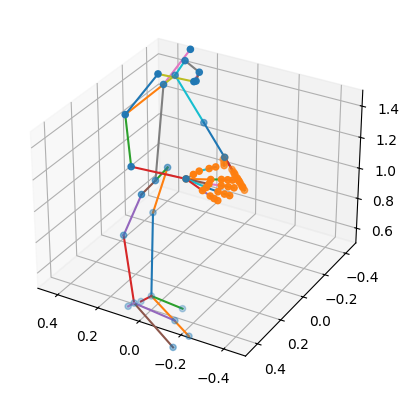

In [15]:
pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_initialized_hands',
    initial_hand_poses_3d,
    xlim=(0.5, -0.5),
    ylim=(0.5, -0.5),
    zlim=(0.5, 1.5)
)

In [16]:
def visualize_poses(frame, body_pose_3d, initial_hands_3d, hand_poses_2d, 
                    camera_intrinsics, rotation, translation, distortion, 
                    frame_idx, cam_name):
    """
    Visualize body poses, 3D hand poses, and 2D hand detections on a frame.
    
    Args:
        frame: Input image/frame
        body_pose_3d: 3D body pose (num_keypoints, 3)
        initial_hands_3d: 3D hand poses (num_hands * num_keypoints_hands, 3)
        hand_poses_2d: Dictionary of 2D hand poses for current frame
        camera_intrinsics: Camera intrinsic matrix (3x3)
        rotation: Camera rotation matrix
        translation: Camera translation vector
        distortion: Distortion coefficients
        frame_idx: Current frame index
        cam_name: Camera name
    """
    # Create copy of frame for drawing
    vis_frame = frame.copy()
    
    # Project and draw 3D body pose
    if body_pose_3d is not None:
        body_2d = project_points(body_pose_3d, camera_intrinsics, 
                               rotation, translation, distortion)
        draw_pose(vis_frame, type('', (), {
            'keypoints': body_2d.reshape(1, -1, 2),
            'keypoint_scores': np.ones((1, len(body_2d)))
        }), pose_type='body')
    
    # Project and draw initial 3D hand poses
    if initial_hands_3d is not None:
        # Left hand (first 21 points)
        left_hand_2d = project_points(initial_hands_3d[:21], camera_intrinsics,
                                    rotation, translation, distortion)
        # Create dummy instance with projected points
        left_hand_instance = type('', (), {
            'keypoints': left_hand_2d.reshape(1, -1, 2),
            'keypoint_scores': np.ones((1, len(left_hand_2d)))
        })
        draw_pose(vis_frame, left_hand_instance, pose_type='hand')
        
        # Right hand (last 21 points)
        right_hand_2d = project_points(initial_hands_3d[21:], camera_intrinsics,
                                     rotation, translation, distortion)
        right_hand_instance = type('', (), {
            'keypoints': right_hand_2d.reshape(1, -1, 2),
            'keypoint_scores': np.ones((1, len(right_hand_2d)))
        })
        draw_pose(vis_frame, right_hand_instance, pose_type='hand')
    
    # Draw 2D detected hand poses
    if cam_name in hand_poses_2d and len(hand_poses_2d[cam_name]) > frame_idx:
        poses_dict = hand_poses_2d[cam_name][frame_idx]
        for hand_id, pose_2d in poses_dict.items():
            if pose_2d is not None:
                draw_pose(vis_frame, pose_2d, pose_type='hand')
    
    return vis_frame

def display_frame(frame):
    """Helper function to display frame with proper window settings"""
    cv2.namedWindow('Poses', cv2.WINDOW_NORMAL)
    cv2.resizeWindow('Poses', 1920, 1080)
    cv2.imshow('Poses', frame)
    if cv2.waitKey(1) == 113:
        cv2.destroyAllWindows()
        return True

In [ ]:
optimized_hand_poses_3d = []
for frame_idx in range(len(poses_3d_body)):
    if frame_idx == 0:
        # Optimize hand poses
        optimized_hand = optimize_poses(
            initial_hand_poses_3d[frame_idx], hand_poses_2d,
            camera_intrinsics, camera_extrinsics, distortion_coeffs
        )
        optimized_hand_poses_3d.append(optimized_hand)

    else:
        # Optimize hand poses
        optimized_hand = optimize_poses(
            prev_optimized_hand, hand_poses_2d,
            camera_intrinsics, camera_extrinsics, distortion_coeffs, 
            frame_idx=frame_idx, previous_pose=prev_optimized_hand
        )
        optimized_hand_poses_3d.append(optimized_hand)
    prev_optimized_hand = optimized_hand
    print(f"Optimized hand pose for frame {frame_idx}: {optimized_hand.shape}")

optimized_hand_poses_3d = np.array(optimized_hand_poses_3d)
optimized_hand_poses_3d.shape

Reprojection error: 55.01886565478192, Temporal consistency: 0, BMC loss: 0.7777188420295715; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 55.79658449681149 
Reprojection error: 35.11423815279919, Temporal consistency: 0, BMC loss: 13.162676811218262; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 48.27691496401745 
Reprojection error: 103.23647550605673, Temporal consistency: 0, BMC loss: 0.7776410579681396; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 104.01411656402487 
Reprojection error: 11.825223137082732, Temporal consistency: 0, BMC loss: 4.618758201599121; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 16.44398133868185 
Optimized hand pose for frame 0: (42, 3)
Reprojection error: 35.42999781086728, Temporal consistency: 0.0, BMC loss: 13.162676811218262; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 48.59267462208554 
Reprojection error: 16.748129562650973, Temporal consistency: 0.251178712568369, BMC loss: 4.627756118774414; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 21.375910799296644 
Reprojec

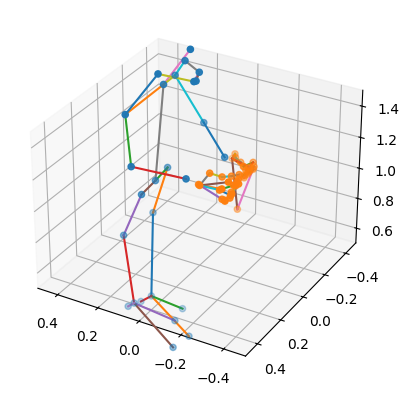

In [24]:
pose2video(
    poses_3d_body,
    output_3d_dir,
    'visualization_optimized_hands',
    optimized_hand_poses_3d,
    xlim=(0.5, -0.5),
    ylim=(0.5, -0.5),
    zlim=(0.5, 1.5)
)

In [25]:
camera = 'gopro11'
print(match_hand_poses(initial_hand_poses_3d[0], hand_poses_2d[camera][0], camera_intrinsics[camera].reshape(3,3), camera_extrinsics[camera][0], camera_extrinsics[camera][1], distortion_coeffs[camera], threshold=120, just_wrist=False))
print(match_hand_poses(optimized_hand, hand_poses_2d[camera][0], camera_intrinsics[camera].reshape(3,3), camera_extrinsics[camera][0], camera_extrinsics[camera][1], distortion_coeffs[camera], threshold=120, just_wrist=False))

((1, 63.38978267639685), (0, 105.99387868217387))
((1, 18.950683731330823), (0, 10.84919199103851))


In [26]:
# Load the first frame of the video
camera = 'gopro10'
cap = cv2.VideoCapture(f'inputs/cha/cha_short/{camera}_synced_cut.MP4')

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = len(poses_3d_body)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Output codec

out_init = cv2.VideoWriter(os.path.join(pose_output_dir, f'{camera}_synced_cut_overlayed_initial.mp4'), fourcc, fps, (frame_width, frame_height))
out_opt = cv2.VideoWriter(os.path.join(pose_output_dir, f'{camera}_synced_cut_overlayed_optimized.mp4'), fourcc, fps, (frame_width, frame_height))



frame_idx = 0    

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Create visualization
    frame_init = visualize_poses(frame, poses_3d_body[frame_idx], initial_hand_poses_3d[frame_idx], hand_poses_2d, camera_intrinsics[camera].reshape(3,3), camera_extrinsics[camera][0], camera_extrinsics[camera][1], distortion_coeffs[camera], frame_idx, camera)
    # plt.figure(figsize=(16, 9))
    # plt.imshow(frame_init)

    frame_opt = visualize_poses(frame, poses_3d_body[frame_idx], optimized_hand_poses_3d[frame_idx], hand_poses_2d, camera_intrinsics[camera].reshape(3,3), camera_extrinsics[camera][0], camera_extrinsics[camera][1], distortion_coeffs[camera], frame_idx, camera)
    # plt.figure(figsize=(16, 9))
    # plt.imshow(frame_opt)

    # Write the frame to the output video
    out_init.write(frame_init)
    out_opt.write(frame_opt)
    frame_idx += 1
    if frame_idx >= total_frames:
        break

cap.release()
out_init.release()
out_opt.release()



In [28]:
def update_wrist_position(body_pose_3d, optimized_hand_pose, side='left'):
    """
    Update wrist position in body pose based on optimized hand pose while
    preserving forearm length.
    """
    # Create a copy of the body pose
    updated_body_pose = body_pose_3d.copy()
    
    # Get indices for arm keypoints based on side
    if side == 'right':
        shoulder_idx, elbow_idx, wrist_idx = 6, 8, 10  # Right arm indices
    else:
        shoulder_idx, elbow_idx, wrist_idx = 5, 7, 9   # Left arm indices
    
    # Extract arm keypoints
    shoulder = body_pose_3d[shoulder_idx]
    elbow = body_pose_3d[elbow_idx]
    current_wrist = body_pose_3d[wrist_idx]
    
    # Get hand wrist position
    hand_wrist = optimized_hand_pose[0]
    
    # Calculate current forearm length (elbow to wrist)
    forearm_length = np.linalg.norm(current_wrist - elbow)
    
    # Calculate direction from elbow to hand wrist
    direction = hand_wrist - elbow
    direction = direction / (np.linalg.norm(direction) + 1e-10)  # Normalize
    
    # Update wrist position while preserving forearm length
    updated_wrist = elbow + direction * forearm_length
    
    # Update body pose
    updated_body_pose[wrist_idx] = updated_wrist
    
    return updated_body_pose

def initialize_hand_pose_for_next_frame(current_hand_pose, next_body_pose, prev_body_pose, side='left'):
    """
    Initialize hand pose for the next frame by moving it to the new wrist position
    while preserving the hand orientation relative to the forearm.
    """
    # Create a copy of the current hand pose
    initialized_hand = current_hand_pose.copy()
    
    # Get indices based on side
    if side == 'right':
        wrist_idx = 10  # Right wrist index
        elbow_idx = 8   # Right elbow index
    else:
        wrist_idx = 9   # Left wrist index
        elbow_idx = 7   # Left elbow index
    
    # Get wrist and elbow positions
    prev_wrist = prev_body_pose[wrist_idx]
    prev_elbow = prev_body_pose[elbow_idx]
    next_wrist = next_body_pose[wrist_idx]
    next_elbow = next_body_pose[elbow_idx]
    
    # Calculate previous and next forearm directions
    prev_forearm = prev_wrist - prev_elbow
    prev_forearm = prev_forearm / np.linalg.norm(prev_forearm)
    
    next_forearm = next_wrist - next_elbow
    next_forearm = next_forearm / np.linalg.norm(next_forearm)
    
    # Calculate rotation from previous to next forearm direction
    rotation = rotation_matrix_from_vectors(prev_forearm, next_forearm)
    
    # Move hand to origin (relative to wrist)
    hand_relative = initialized_hand - current_hand_pose[0]
    
    # Rotate hand
    hand_rotated = np.dot(hand_relative, rotation.T)
    
    # Move hand to new wrist position
    initialized_hand = hand_rotated + next_wrist
    
    return initialized_hand

def rotation_matrix_from_vectors(vec1, vec2):
    """Calculate rotation matrix that rotates vec1 to vec2"""
    v = np.cross(vec1, vec2)
    c = np.dot(vec1, vec2)
    s = np.linalg.norm(v)
    
    if s == 0:
        return np.eye(3)
        
    kmat = np.array([[0, -v[2], v[1]], 
                     [v[2], 0, -v[0]], 
                     [-v[1], v[0], 0]])
    return np.eye(3) + kmat + kmat.dot(kmat) * ((1 - c) / (s ** 2))

In [29]:
optimized_hand_poses_3d = []
updated_body_poses_3d = np.copy(poses_3d_body)  # Create a copy to preserve original poses

for frame_idx in range(len(poses_3d_body)):
    if frame_idx == 0:
        # For the first frame, use initial hand poses
        initial_left_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='left')
        initial_right_hand = orient_canonical_hand(CANONICAL_HAND_POSE_3D, poses_3d_body[frame_idx], side='right')
        initial_hands = np.concatenate([initial_left_hand, initial_right_hand])
        
        # Optimize hand poses
        optimized_hand = optimize_poses(
            initial_hands, hand_poses_2d,
            camera_intrinsics, camera_extrinsics, distortion_coeffs
        )
        optimized_hand_poses_3d.append(optimized_hand)
        
        # Update body pose wrist positions based on optimized hands
        updated_body = update_wrist_position(poses_3d_body[frame_idx], optimized_hand[:21], side='left')
        updated_body = update_wrist_position(updated_body, optimized_hand[21:], side='right')
        updated_body_poses_3d[frame_idx] = updated_body
        
        prev_optimized_hand = optimized_hand
        prev_body_pose = updated_body
    else:
        # For subsequent frames, initialize hands based on body pose movement
        left_hand = initialize_hand_pose_for_next_frame(
            prev_optimized_hand[:21], 
            poses_3d_body[frame_idx], 
            poses_3d_body[frame_idx-1], 
            side='left'
        )
        right_hand = initialize_hand_pose_for_next_frame(
            prev_optimized_hand[21:], 
            poses_3d_body[frame_idx], 
            poses_3d_body[frame_idx-1], 
            side='right'
        )
        initial_hands = np.concatenate([left_hand, right_hand])
        
        # Optimize hand poses
        optimized_hand = optimize_poses(
            initial_hands, hand_poses_2d,
            camera_intrinsics, camera_extrinsics, distortion_coeffs, 
            frame_idx=frame_idx, previous_pose=prev_optimized_hand
        )
        optimized_hand_poses_3d.append(optimized_hand)
        
        # Update body pose wrist positions based on optimized hands
        updated_body = update_wrist_position(poses_3d_body[frame_idx], optimized_hand[:21], side='left')
        updated_body = update_wrist_position(updated_body, optimized_hand[21:], side='right')
        updated_body_poses_3d[frame_idx] = updated_body
        
        prev_optimized_hand = optimized_hand
        prev_body_pose = updated_body
        
    print(f"Optimized hand pose for frame {frame_idx}: {optimized_hand.shape}")

optimized_hand_poses_3d = np.array(optimized_hand_poses_3d)

Reprojection error: 55.01886565478192, Temporal consistency: 0, BMC loss: 0.7777188420295715; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 55.79658449681149 
Reprojection error: 35.11423815279919, Temporal consistency: 0, BMC loss: 13.162676811218262; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 48.27691496401745 
Reprojection error: 103.23647550605673, Temporal consistency: 0, BMC loss: 0.7776410579681396; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 104.01411656402487 
Reprojection error: 11.825223137082732, Temporal consistency: 0, BMC loss: 4.618758201599121; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 16.44398133868185 
Optimized hand pose for frame 0: (42, 3)
Reprojection error: 39.659648307786384, Temporal consistency: 0.1131537427163661, BMC loss: 13.16269302368164; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 52.8223526468423 
Reprojection error: 25.550470260596526, Temporal consistency: 0.17406993154564443, BMC loss: 4.0052490234375; 
Lamdas: [1.0, 0.0001, 1.0]; 
Total loss: 29.55573669102

KeyboardInterrupt: 

In [ ]:
pose2video(
    updated_body_poses_3d,  # Use updated body poses with corrected wrist positions
    output_3d_dir,
    'visualization_optimized_hands_and_body',
    optimized_hand_poses_3d,
    xlim=(0.5, -0.5),
    ylim=(0.5, -0.5),
    zlim=(0.5, 1.5)
)